In [1]:
import cv2
import mediapipe as mp
import numpy as np
from scipy.spatial import distance as dist
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# Initialize MediaPipe
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True
)

# EAR calculation
def calculate_EAR(eye_points):
    A = dist.euclidean(eye_points[1], eye_points[5])
    B = dist.euclidean(eye_points[2], eye_points[4])
    C = dist.euclidean(eye_points[0], eye_points[3])
    return (A + B) / (2.0 * C)

LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

EAR_THRESHOLD = 0.21

# Webcam capture function
def capture_frame():
    js = Javascript('''
        async function capture() {
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();
            await new Promise(resolve => setTimeout(resolve, 1000));
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            video.remove();
            return canvas.toDataURL('image/jpeg');
        }
        capture();
    ''')
    display(js)
    data = eval_js("capture()")
    binary = b64decode(data.split(',')[1])
    image = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(image, cv2.IMREAD_COLOR)

# Capture frame
frame = capture_frame()

rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
results = face_mesh.process(rgb)

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        h, w, _ = frame.shape

        left_eye = []
        right_eye = []

        for idx in LEFT_EYE:
            x = int(face_landmarks.landmark[idx].x * w)
            y = int(face_landmarks.landmark[idx].y * h)
            left_eye.append((x, y))

        for idx in RIGHT_EYE:
            x = int(face_landmarks.landmark[idx].x * w)
            y = int(face_landmarks.landmark[idx].y * h)
            right_eye.append((x, y))

        left_EAR = calculate_EAR(left_eye)
        right_EAR = calculate_EAR(right_eye)

        ear = (left_EAR + right_EAR) / 2.0

        cv2.putText(frame, f"EAR: {ear:.2f}", (30,40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

        if ear < EAR_THRESHOLD:
            cv2.putText(frame, "DROWSY!", (30,90),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)

cv2_imshow(frame)

ModuleNotFoundError: No module named 'google'

<IPython.core.display.Javascript object>

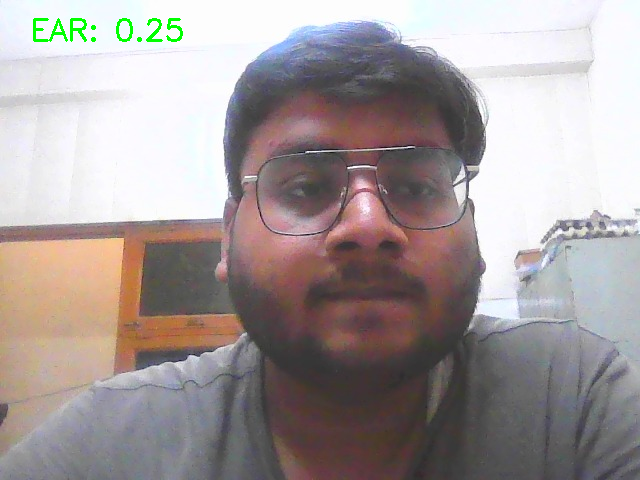

<IPython.core.display.Javascript object>

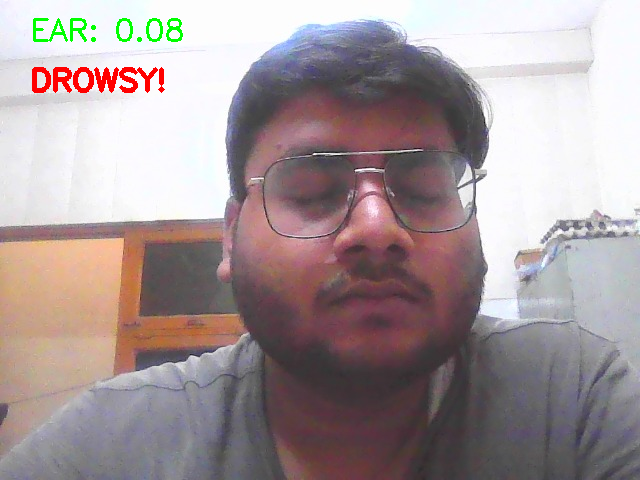

<IPython.core.display.Javascript object>

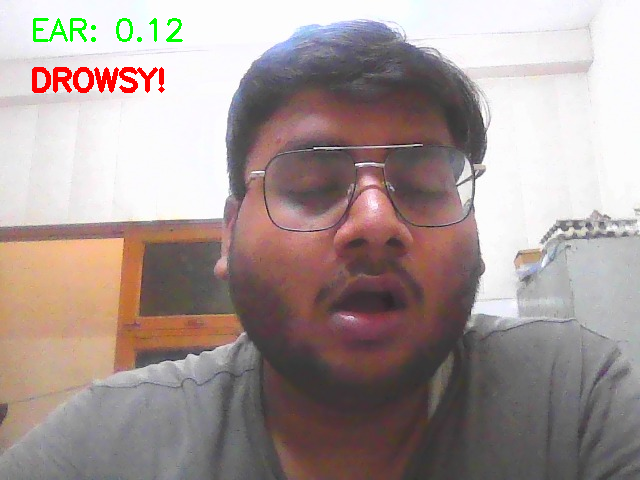

<IPython.core.display.Javascript object>

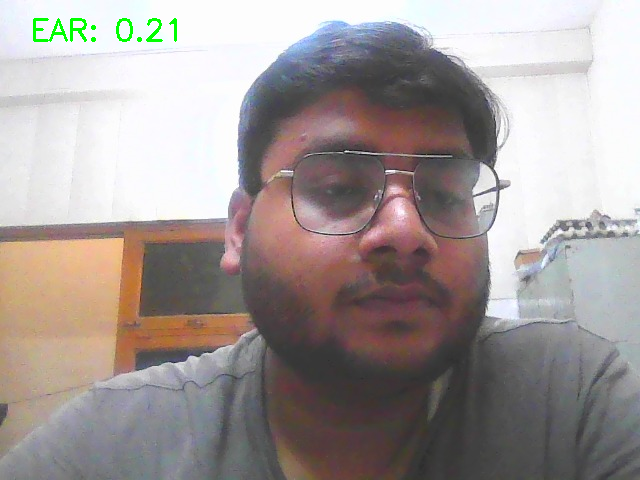

<IPython.core.display.Javascript object>

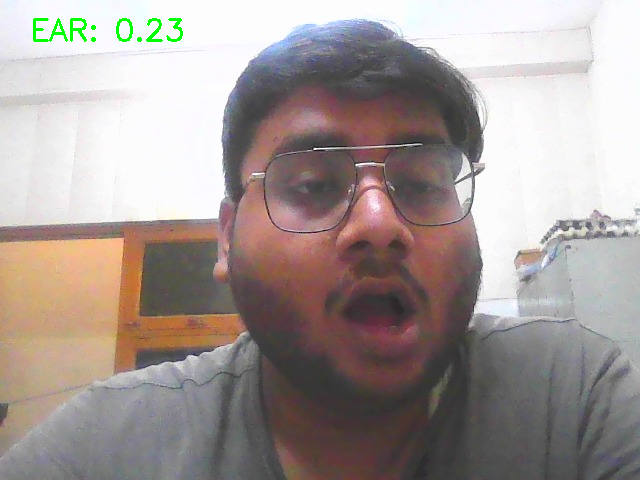

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from scipy.spatial import distance as dist
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import time

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(refine_landmarks=True)

def calculate_EAR(eye_points):
    A = dist.euclidean(eye_points[1], eye_points[5])
    B = dist.euclidean(eye_points[2], eye_points[4])
    C = dist.euclidean(eye_points[0], eye_points[3])
    return (A + B) / (2.0 * C)

LEFT_EYE = [33,160,158,133,153,144]
RIGHT_EYE = [362,385,387,263,373,380]

EAR_THRESHOLD = 0.21

def capture_frame():
    js = Javascript('''
        async function capture() {
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();
            await new Promise(resolve => setTimeout(resolve, 200));
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            return canvas.toDataURL('image/jpeg');
        }
        capture();
    ''')
    display(js)
    data = eval_js("capture()")
    binary = b64decode(data.split(',')[1])
    image = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(image, cv2.IMREAD_COLOR)

for i in range(5):   # capture 5 frames
    frame = capture_frame()
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            h, w, _ = frame.shape
            left_eye = [(int(face_landmarks.landmark[idx].x*w),
                         int(face_landmarks.landmark[idx].y*h)) for idx in LEFT_EYE]
            right_eye = [(int(face_landmarks.landmark[idx].x*w),
                          int(face_landmarks.landmark[idx].y*h)) for idx in RIGHT_EYE]

            ear = (calculate_EAR(left_eye) + calculate_EAR(right_eye)) / 2.0

            cv2.putText(frame, f"EAR: {ear:.2f}", (30,40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

            if ear < EAR_THRESHOLD:
                cv2.putText(frame, "DROWSY!", (30,90),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)

    cv2_imshow(frame)
    time.sleep(1)

<IPython.core.display.Javascript object>

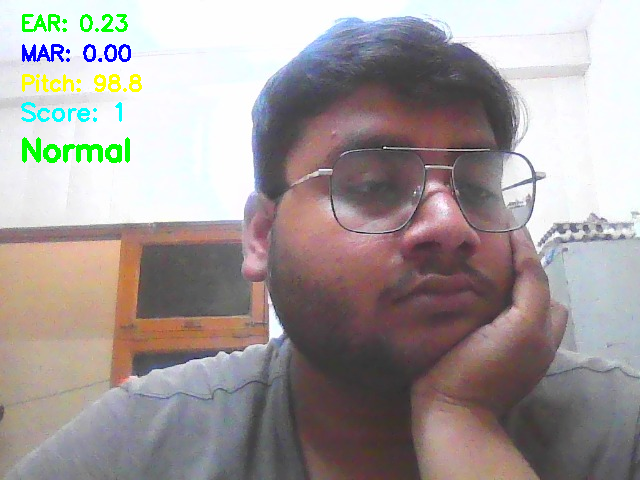

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from scipy.spatial import distance as dist
import math

# -----------------------------
# MediaPipe Setup
# -----------------------------
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(refine_landmarks=True)

LEFT_EYE = [33,160,158,133,153,144]
RIGHT_EYE = [362,385,387,263,373,380]
MOUTH = [13,14,78,308]
NOSE_TIP = 1
CHIN = 152

def euclidean(p1, p2):
    return dist.euclidean(p1, p2)

def calculate_EAR(eye):
    A = euclidean(eye[1], eye[5])
    B = euclidean(eye[2], eye[4])
    C = euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def calculate_MAR(landmarks, w, h):
    upper = (int(landmarks[MOUTH[0]].x * w),
             int(landmarks[MOUTH[0]].y * h))
    lower = (int(landmarks[MOUTH[1]].x * w),
             int(landmarks[MOUTH[1]].y * h))
    left = (int(landmarks[MOUTH[2]].x * w),
            int(landmarks[MOUTH[2]].y * h))
    right = (int(landmarks[MOUTH[3]].x * w),
             int(landmarks[MOUTH[3]].y * h))
    return euclidean(upper, lower) / euclidean(left, right)

def calculate_head_pitch(landmarks, w, h):
    nose = (int(landmarks[NOSE_TIP].x * w),
            int(landmarks[NOSE_TIP].y * h))
    chin = (int(landmarks[CHIN].x * w),
            int(landmarks[CHIN].y * h))
    dx = chin[0] - nose[0]
    dy = chin[1] - nose[1]
    return math.degrees(math.atan2(dy, dx))

def compute_score(EAR, MAR, pitch):
    score = 0
    if EAR < 0.21:
        score += 2
    if MAR > 0.6:
        score += 1
    if pitch > 20:
        score += 1
    if score >= 3:
        return score, "High Drowsiness Risk"
    elif score == 2:
        return score, "Moderate Risk"
    else:
        return score, "Normal"

# -----------------------------
# Capture Frame
# -----------------------------
cap = cv2.VideoCapture(0)
ret, frame = cap.read()

if ret:
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            h, w, _ = frame.shape

            left_eye = [(int(face_landmarks.landmark[i].x * w),
                         int(face_landmarks.landmark[i].y * h)) for i in LEFT_EYE]

            right_eye = [(int(face_landmarks.landmark[i].x * w),
                          int(face_landmarks.landmark[i].y * h)) for i in RIGHT_EYE]

            EAR = (calculate_EAR(left_eye) +
                   calculate_EAR(right_eye)) / 2.0

            MAR = calculate_MAR(face_landmarks.landmark, w, h)
            pitch = calculate_head_pitch(face_landmarks.landmark, w, h)

            score, status = compute_score(EAR, MAR, pitch)

            cv2.putText(frame, f"EAR: {EAR:.2f}", (20,30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

            cv2.putText(frame, f"MAR: {MAR:.2f}", (20,60),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

            cv2.putText(frame, f"Pitch: {pitch:.1f}", (20,90),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)

            cv2.putText(frame, f"Score: {score}", (20,120),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,0), 2)

            cv2.putText(frame, status, (20,160),
                        cv2.FONT_HERSHEY_SIMPLEX, 1,
                        (0,0,255) if score >= 3 else (0,255,0), 3)

    else:
        print("No face detected")

    cv2.imshow('Drowsiness Detection', frame)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

cap.release()


In [ ]:
import time
import json

NUM_CAPTURES = 5
INTERVAL_SECONDS = 2

score_history = []  # Initialize a list to store scores
all_frame_results = [] # List to store results for all frames

# Open webcam
cap = cv2.VideoCapture(0)
time.sleep(0.5)  # Allow camera to warm up

for i in range(NUM_CAPTURES):

    print(f"\nCapturing frame {i+1}...")

    ret, frame = cap.read()
    
    if not ret:
        print(f"Failed to capture frame {i+1}")
        continue

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    frame_data = {"frame_number": i + 1}

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            h, w, _ = frame.shape

            left_eye = [(int(face_landmarks.landmark[j].x * w),
                         int(face_landmarks.landmark[j].y * h)) for j in LEFT_EYE]

            right_eye = [(int(face_landmarks.landmark[j].x * w),
                          int(face_landmarks.landmark[j].y * h)) for j in RIGHT_EYE]

            EAR = (calculate_EAR(left_eye) +
                   calculate_EAR(right_eye)) / 2.0

            MAR = calculate_MAR(face_landmarks.landmark, w, h)
            pitch = calculate_head_pitch(face_landmarks.landmark, w, h)

            score, status = compute_score(EAR, MAR, pitch)

            # Add current score to history and keep only last 3
            score_history.append(score)
            if len(score_history) > 3:
                score_history.pop(0) # Remove the oldest score

            running_score_sum = None
            avg_score = None
            multiple_drowsy_instances = False

            # Calculate running score if enough history exists
            if len(score_history) == 3:
                running_score_sum = sum(score_history)
                avg_score = running_score_sum / 3
                if avg_score > 2:
                    multiple_drowsy_instances = True

            frame_data.update({
                "EAR": round(EAR, 2),
                "MAR": round(MAR, 2),
                "pitch": round(pitch, 1),
                "score": score,
                "status": status,
                "running_score_sum": running_score_sum,
                "average_score": round(avg_score, 2) if avg_score is not None else None,
                "multiple_drowsy_instances": multiple_drowsy_instances
            })

    else:
        frame_data["status"] = "No face detected"

    all_frame_results.append(frame_data)

    if i < NUM_CAPTURES - 1:
        print(f"Waiting {INTERVAL_SECONDS} seconds...\n")
        time.sleep(INTERVAL_SECONDS)

cap.release()

print(json.dumps(all_frame_results, indent=4))



Capturing frame 1...


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Waiting 2 seconds...


Capturing frame 2...


<IPython.core.display.Javascript object>

...

Waiting 2 seconds...


Capturing frame 4...


<IPython.core.display.Javascript object>

Waiting 2 seconds...


Capturing frame 5...


<IPython.core.display.Javascript object>

[
    {
        "frame_number": 1,
        "EAR": 0.27,
        "MAR": 0.0,
        "pitch": 91.6,
        "score": 1,
        "status": "Normal",
        "running_score_sum": null,
        "average_score": null,
        "multiple_drowsy_instances": false
    },
    {
        "frame_number": 2,
        "EAR": 0.2,
        "MAR": 0.0,
        "pitch": 89.6,
        "score": 3,
        "status": "High Drowsiness Risk",
        "running_score_sum": null,
        "average_score": null,
        "multiple_drowsy_instances": false
    },
    {
        "frame_number": 3,
        "EAR": 0.18,
        "MAR": 0.0,
        "pitch": 88.8,
        "score": 3,
        "status": "High Drowsiness Risk",
        "running_score_sum": 7,
        "average_score": 2.33,
        "multiple_drowsy_instances": true
    },
    {
        "frame_number": 4,
        "EAR": 0.24,
        "MAR": 0.43,
        "pitch": 93.0,
        "score": 1,
        "status": "Normal",
        "running_score_sum": 7,
        "avera

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from scipy.spatial import distance as dist
import time

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(refine_landmarks=True)

def calculate_EAR(eye_points):
    A = dist.euclidean(eye_points[1], eye_points[5])
    B = dist.euclidean(eye_points[2], eye_points[4])
    C = dist.euclidean(eye_points[0], eye_points[3])
    return (A + B) / (2.0 * C)

LEFT_EYE = [33,160,158,133,153,144]
RIGHT_EYE = [362,385,387,263,373,380]

EAR_THRESHOLD = 0.21

# Open webcam
cap = cv2.VideoCapture(0)

# Allow camera to warm up
time.sleep(0.5)

for i in range(5):   # capture 5 frames
    ret, frame = cap.read()
    
    if not ret:
        print(f"Failed to capture frame {i+1}")
        continue
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            h, w, _ = frame.shape
            left_eye = [(int(face_landmarks.landmark[idx].x*w),
                         int(face_landmarks.landmark[idx].y*h)) for idx in LEFT_EYE]
            right_eye = [(int(face_landmarks.landmark[idx].x*w),
                          int(face_landmarks.landmark[idx].y*h)) for idx in RIGHT_EYE]

            ear = (calculate_EAR(left_eye) + calculate_EAR(right_eye)) / 2.0

            cv2.putText(frame, f"EAR: {ear:.2f}", (30,40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

            if ear < EAR_THRESHOLD:
                cv2.putText(frame, "DROWSY!", (30,90),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)

    cv2.imshow(f'Frame {i+1}/5', frame)
    cv2.waitKey(1000)  # Display for 1 second

cv2.destroyAllWindows()
cap.release()
